In [18]:
import arxiv
import time
import requests
import json
import random
from collections import Counter

# API key for Semantic Scholar
API_KEY = "VXlIELXyFt71EvmsfAEkjAXsVvtNyUj3N2kAKiGb"

# Exponential backoff function for rate limiting
def backoff_retry(initial_delay=5, max_delay=120, max_retries=10):
    """Decorator for exponential backoff retry logic."""
    def decorator(func):
        def wrapper(*args, **kwargs):
            delay = initial_delay
            retries = 0
            
            while retries < max_retries:
                try:
                    return func(*args, **kwargs)
                except requests.exceptions.RequestException as e:
                    if hasattr(e.response, 'status_code') and e.response.status_code == 429:
                        retries += 1
                        actual_delay = delay + random.uniform(0, delay * 0.1)  # Add jitter
                        print(f"  Rate limit exceeded. Retry {retries}/{max_retries}. Waiting for {actual_delay:.2f} seconds...")
                        time.sleep(actual_delay)
                        delay = min(delay * 2, max_delay)  # Exponential backoff
                    else:
                        raise e
            
            raise Exception(f"Maximum retries ({max_retries}) exceeded.")
        return wrapper
    return decorator

# Function to get paper details from arXiv
def get_arxiv_paper(arxiv_id):
    """Retrieve paper details from arXiv using its ID."""
    try:
        arxiv_client = arxiv.Client()
        search = arxiv.Search(id_list=[arxiv_id])
        paper = next(arxiv_client.results(search))
        return {
            'title': paper.title,
            'abstract': paper.summary,
            'authors': [author.name for author in paper.authors],
            'url': paper.entry_id,
            'published': paper.published
        }
    except Exception as e:
        print(f"Error retrieving paper from arXiv: {str(e)}")
        return None

# Function to get paper details from Semantic Scholar API with retry
@backoff_retry()
def get_semantic_scholar_paper(arxiv_id):
    """Retrieve paper details from Semantic Scholar API using arXiv ID."""
    # Clean arXiv ID by removing version if present
    clean_id = arxiv_id.split('v')[0] if 'v' in arxiv_id else arxiv_id
    
    headers = {'x-api-key': API_KEY}
    api_url = f"https://api.semanticscholar.org/graph/v1/paper/arXiv:{clean_id}?fields=paperId,title,year,authors,citationCount"
    
    response = requests.get(api_url, headers=headers)
    
    if response.status_code == 200:
        return response.json()
    elif response.status_code == 429:
        # Let the backoff_retry decorator handle this
        response.raise_for_status()
    else:
        print(f"Error retrieving paper from Semantic Scholar API: Status code {response.status_code}")
        print(f"Response: {response.text}")
        return None

# Function to get papers that cite a given paper with retry
@backoff_retry()
def get_citations(paper_id, limit=20, offset=0):
    """Get papers that cite the given paper from Semantic Scholar API."""
    headers = {'x-api-key': API_KEY}
    api_url = f"https://api.semanticscholar.org/graph/v1/paper/{paper_id}/citations?fields=citingPaper.paperId,citingPaper.title,citingPaper.year&limit={limit}&offset={offset}"
    
    response = requests.get(api_url, headers=headers)
    
    if response.status_code == 200:
        data = response.json()
        if 'data' in data and data['data']:
            if offset == 0:  # Only print sample on first page
                print(f"  Sample citation data structure: {json.dumps(data['data'][0], indent=2)}")
        return data
    elif response.status_code == 429:
        # Let the backoff_retry decorator handle this
        response.raise_for_status()
    else:
        print(f"  Error retrieving citations: Status code {response.status_code}")
        print(f"  Response: {response.text}")
        return {'data': []}

# Function to get all citations for a paper (handling pagination)
def get_all_citations(paper_id, total_citations):
    """Get all papers that cite the given paper, handling pagination and rate limits."""
    all_citations = []
    offset = 0
    limit = 20  # Small batch size to reduce rate limiting issues
    
    # Calculate expected number of pages
    expected_pages = (total_citations + limit - 1) // limit
    current_page = 1
    
    print(f"  Fetching all {total_citations} citations (approx. {expected_pages} pages)...")
    
    while True:
        print(f"  Retrieving page {current_page}/{expected_pages} (citations {offset+1}-{min(offset+limit, total_citations)})...")
        
        # Get current page of citations
        result = get_citations(paper_id, limit=limit, offset=offset)
        citations = result.get('data', [])
        
        if not citations:
            print(f"  No more citations found after {len(all_citations)} citations.")
            break
            
        all_citations.extend(citations)
        print(f"  Retrieved {len(all_citations)}/{total_citations} citations so far...")
        
        offset += limit
        current_page += 1
        
        # If we got fewer results than the limit, we've reached the end
        if len(citations) < limit:
            break
        
        # If we've retrieved all expected citations, break
        if len(all_citations) >= total_citations:
            break
            
        # Be nice to the API - add small random delay
        time.sleep(random.uniform(1, 3))
    
    print(f"  Retrieved {len(all_citations)} citations total.")
    return all_citations

# Function to collect citation data for a paper
def collect_citation_data(arxiv_id):
    """Collect all citation data for a paper."""
    print(f"Processing paper: {arxiv_id}...")
    
    # Get paper details
    arxiv_details = get_arxiv_paper(arxiv_id)
    ss_details = get_semantic_scholar_paper(arxiv_id)
    
    if not arxiv_details:
        print(f"Could not retrieve paper information for {arxiv_id} from arXiv.")
        return None, []
        
    if not ss_details:
        print(f"Could not retrieve paper information for {arxiv_id} from Semantic Scholar.")
        return arxiv_details, []
    
    # Get paper ID from Semantic Scholar
    paper_id = ss_details.get('paperId')
    if not paper_id:
        print(f"No paper ID found for {arxiv_id}")
        return arxiv_details, []
    
    # Get citation count
    citation_count = ss_details.get('citationCount', 0)
    print(f"  Paper has {citation_count} citations according to Semantic Scholar.")
    
    # Get all citations
    print(f"  Retrieving all citations...")
    citations = get_all_citations(paper_id, citation_count)
    print(f"  Retrieved {len(citations)} citations total.")
    
    return arxiv_details, citations

# Function to extract paper ID from citation data
def extract_citing_paper_id(citation):
    """Extract the citing paper ID from a citation object with proper error handling."""
    try:
        # First try the expected structure based on the API documentation
        if 'citingPaper' in citation and 'paperId' in citation['citingPaper']:
            return citation['citingPaper']['paperId']
        
        # Alternative structures that might be present
        if 'paperId' in citation:
            return citation['paperId']
            
        # Return None if we can't find it
        print(f"  Warning: Could not extract paper ID from citation: {citation}")
        return None
    except Exception as e:
        print(f"  Error extracting paper ID: {str(e)}")
        return None

# Function to analyze citation overlaps
def analyze_citation_overlaps(paper_details, citations_lists, full_citation_counts):
    """Analyze overlaps between citation lists."""
    # Extract paper IDs from citations
    citation_ids = []
    for citations in citations_lists:
        # Extract paper IDs with proper error handling
        ids = set()
        for citation in citations:
            paper_id = extract_citing_paper_id(citation)
            if paper_id:
                ids.add(paper_id)
        citation_ids.append(ids)
        
    # Print some stats about the extracted IDs
    for i, ids in enumerate(citation_ids):
        print(f"  Extracted {len(ids)} unique paper IDs from {len(citations_lists[i])} citations for paper {i+1}")
    
    # Paper names for reporting
    paper_names = [details['title'] for details in paper_details]
    
    # Calculate statistics
    results = {
        'citation_counts': full_citation_counts,
        'citation_sample_counts': [len(ids) for ids in citation_ids],
        'pairwise_overlaps': [],
        'main_comparison': []
    }
    
    # Calculate pairwise overlaps
    for i in range(len(citations_lists)):
        for j in range(i+1, len(citations_lists)):
            overlap = citation_ids[i].intersection(citation_ids[j])
            
            # Calculate percentages (protect against division by zero)
            percentage_i = (len(overlap) / len(citation_ids[i]) * 100) if citation_ids[i] else 0
            percentage_j = (len(overlap) / len(citation_ids[j]) * 100) if citation_ids[j] else 0
            
            results['pairwise_overlaps'].append({
                'paper_pair': f"{paper_names[i]} and {paper_names[j]}",
                'overlap_count': len(overlap),
                'overlap_percentage_1': percentage_i,
                'overlap_percentage_2': percentage_j,
            })
    
    # Main comparisons: how many papers that cite papers 1 and 2 also cite paper 0 (Chain of Thought)
    cot_citation_ids = citation_ids[0]
    for i in range(1, len(citations_lists)):
        overlap = citation_ids[i].intersection(cot_citation_ids)
        
        # Calculate percentage (protect against division by zero)
        percentage = (len(overlap) / len(citation_ids[i]) * 100) if citation_ids[i] else 0
        
        results['main_comparison'].append({
            'comparison': f"Papers citing both {paper_names[0]} and {paper_names[i]}",
            'overlap_count': len(overlap),
            'overlap_fraction': f"{len(overlap)}/{len(citation_ids[i])}",
            'overlap_percentage': percentage,
        })
    
    # Combined comparison: papers citing either paper 1 or 2 that also cite paper 0
    papers_citing_either = citation_ids[1].union(citation_ids[2]).union(citation_ids[3]).union(citation_ids[4])
    overlap_with_cot = papers_citing_either.intersection(cot_citation_ids)
    
    # Calculate percentage (protect against division by zero)
    percentage = (len(overlap_with_cot) / len(papers_citing_either) * 100) if papers_citing_either else 0
    
    results['combined_comparison'] = {
        'comparison': f"Papers citing any of the other papers that also cite {paper_names[0]}",
        'overlap_count': len(overlap_with_cot),
        'overlap_fraction': f"{len(overlap_with_cot)}/{len(papers_citing_either)}",
        'overlap_percentage': percentage,
    }
    
    return results

# Main function
def main():
    """Main function to run the analysis"""
    # Define the papers to analyze
    paper_ids = [
        "2201.11903",  # https://arxiv.org/abs/2201.11903 (Chain of Thought)
        "2005.11401",  # https://arxiv.org/abs/2005.11401
        "2212.10560",  # https://arxiv.org/abs/2212.10560
        "2210.11610",  # https://arxiv.org/abs/2210.11610
        "2206.14858"   # https://arxiv.org/abs/2206.14858
    ]
    
    # Collect citation data for each paper
    paper_details = []
    citation_lists = []
    full_citation_counts = []
    
    for arxiv_id in paper_ids:
        details, citations = collect_citation_data(arxiv_id)
        if details:
            paper_details.append(details)
            citation_lists.append(citations)
            
            # Get the full citation count from Semantic Scholar
            ss_details = get_semantic_scholar_paper(arxiv_id)
            if ss_details and 'citationCount' in ss_details:
                full_citation_counts.append(ss_details['citationCount'])
            else:
                full_citation_counts.append(len(citations))
            
        # Be nice to the APIs - longer wait between papers
        time.sleep(10)
    
    # Make sure we have data for all papers
    if len(paper_details) != len(paper_ids) or len(citation_lists) != len(paper_ids):
        print("Error: Could not collect data for all papers.")
        return
    
    # Analyze the citation overlaps
    print("\nAnalyzing citation overlaps...")
    results = analyze_citation_overlaps(paper_details, citation_lists, full_citation_counts)
    
    # Display results
    print("\n=== Citation Analysis Results ===\n")
    
    print("Paper Citation Counts (Total):")
    for i, count in enumerate(results['citation_counts']):
        print(f"  {paper_details[i]['title']}: {count} citations")
    
    print("\nCitation Counts (Successfully Retrieved):")
    for i, count in enumerate(results['citation_sample_counts']):
        print(f"  {paper_details[i]['title']}: {count} unique paper IDs extracted")
    
    print("\nPairwise Citation Overlaps:")
    for overlap in results['pairwise_overlaps']:
        print(f"  {overlap['paper_pair']}:")
        print(f"    Papers citing both: {overlap['overlap_count']}")
        print(f"    Overlap percentages: {overlap['overlap_percentage_1']:.2f}% and {overlap['overlap_percentage_2']:.2f}%")
    
    print("\nMain Comparison (Papers citing Chain of Thought):")
    for comp in results['main_comparison']:
        print(f"  {comp['comparison']}:")
        print(f"    Overlap count: {comp['overlap_count']} papers")
        print(f"    Overlap fraction: {comp['overlap_fraction']}")
        print(f"    Overlap percentage: {comp['overlap_percentage']:.2f}%")
    
    print("\nCombined Comparison:")
    combined = results['combined_comparison']
    print(f"  {combined['comparison']}:")
    print(f"    Overlap count: {combined['overlap_count']} papers")
    print(f"    Overlap fraction: {combined['overlap_fraction']}")
    print(f"    Overlap percentage: {combined['overlap_percentage']:.2f}%")

if __name__ == "__main__":
    main()

Processing paper: 2201.11903...
  Paper has 7312 citations according to Semantic Scholar.
  Retrieving all citations...
  Fetching all 7312 citations (approx. 366 pages)...
  Retrieving page 1/366 (citations 1-20)...
  Rate limit exceeded. Retry 1/10. Waiting for 5.05 seconds...
  Sample citation data structure: {
  "citingPaper": {
    "paperId": "257ac2d453cc8b09220e5ee381c31ee10ae1b9be",
    "title": "MaViLa: Unlocking new potentials in smart manufacturing through vision language models",
    "year": 2025
  }
}
  Retrieved 20/7312 citations so far...
  Retrieving page 2/366 (citations 21-40)...
  Retrieved 40/7312 citations so far...
  Retrieving page 3/366 (citations 41-60)...
  Retrieved 60/7312 citations so far...
  Retrieving page 4/366 (citations 61-80)...
  Retrieved 80/7312 citations so far...
  Retrieving page 5/366 (citations 81-100)...
  Retrieved 100/7312 citations so far...
  Retrieving page 6/366 (citations 101-120)...
  Retrieved 120/7312 citations so far...
  Retrievi

Creating improved 4-circle Venn diagrams...
Version 1: Improved layout...


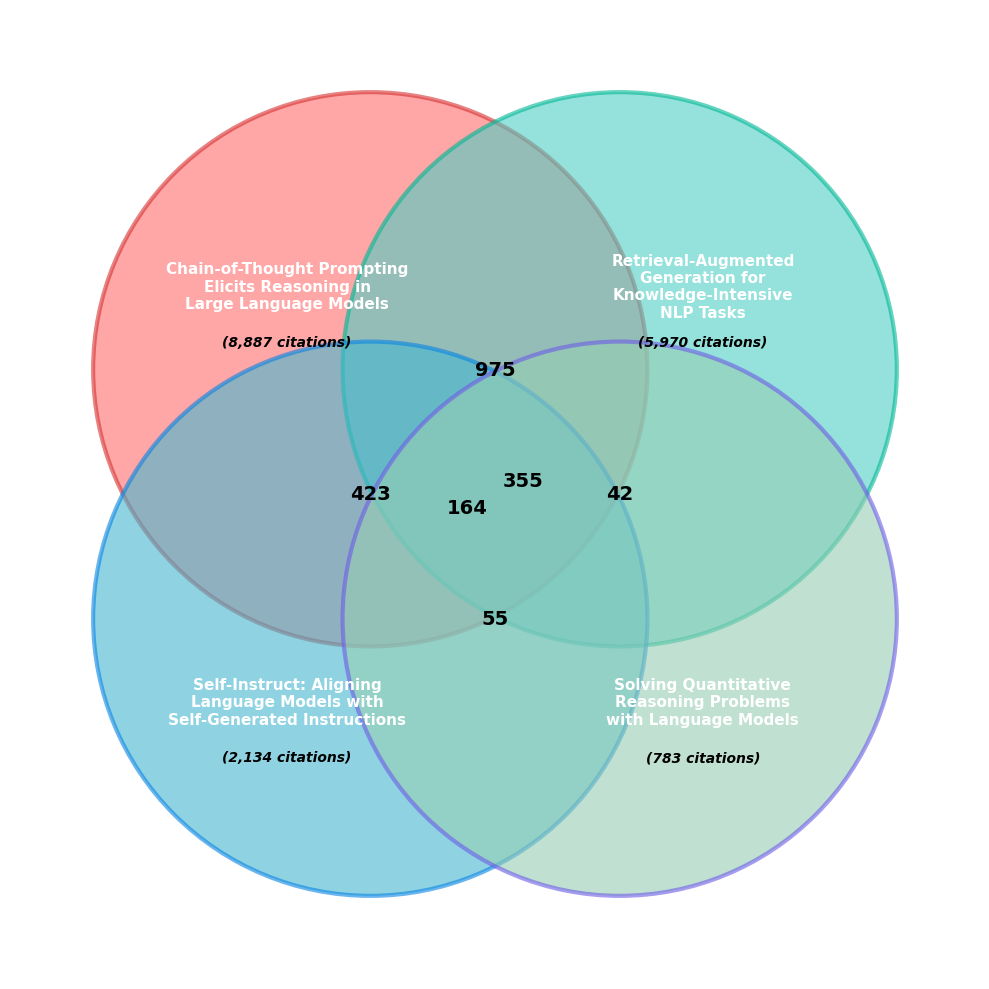

Version 2: Modern design...


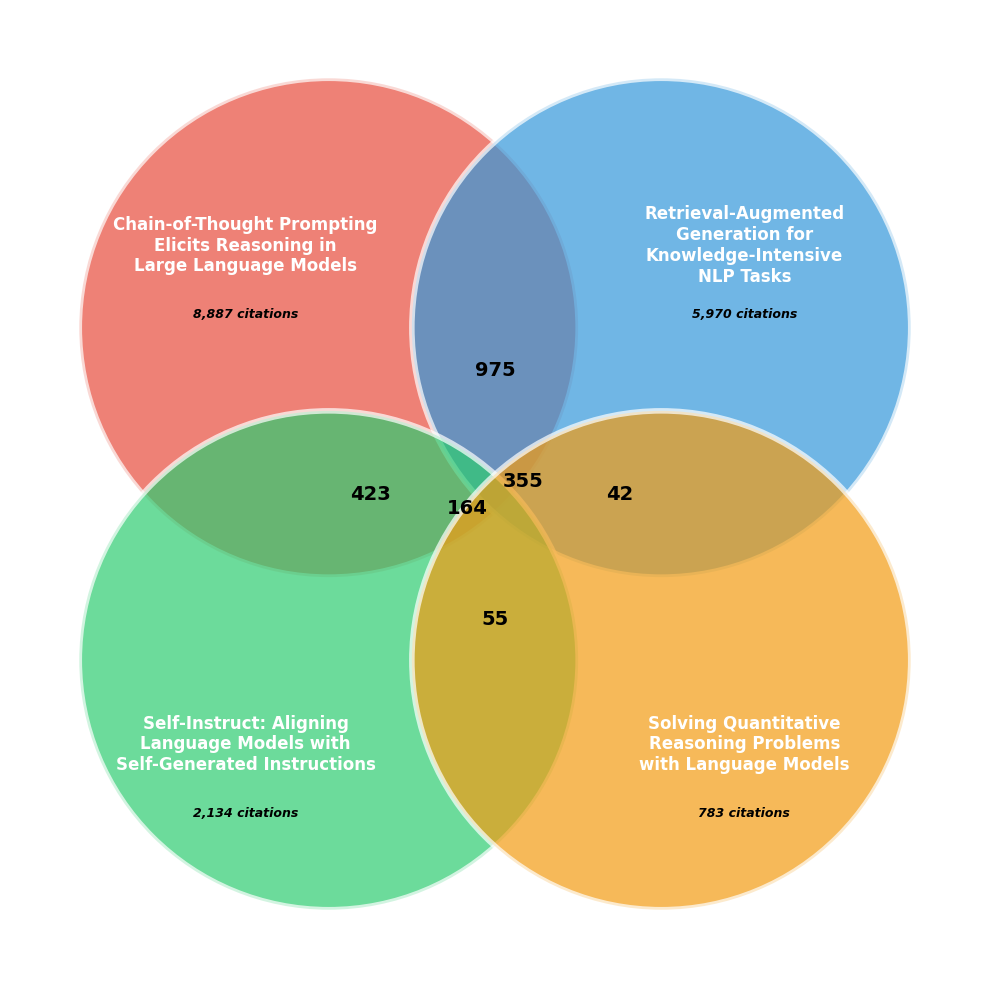

Improved Venn diagrams created successfully!
Key improvements:
- Titles and citation counts properly aligned inside circles
- Citation numbers displayed in black
- Larger, clearer overlap regions with properly positioned numbers
- Clean, publication-ready design with better text positioning

Files saved:
- citation_venn_improved.pdf/png
- citation_venn_modern.pdf/png


In [23]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.patches import Circle, FancyBboxPatch
import seaborn as sns
from matplotlib.patches import ConnectionPatch

def create_improved_venn_diagram(csv_file_path):
    """
    Create an improved 4-circle Venn diagram with titles inside circles and clean styling
    
    Args:
        csv_file_path (str): Path to the CSV file containing citation overlap matrix
    """
    
    # Read the CSV file
    df = pd.read_csv(csv_file_path, index_col=0)
    
    # Extract data for Papers 1, 2, 3, and 5 (ignoring Paper 4)
    papers = ['Paper_1', 'Paper_2', 'Paper_3', 'Paper_5']
    
    # Paper titles (full titles without paper numbers)
    paper_titles = {
        'Paper_1': 'Chain-of-Thought Prompting\nElicits Reasoning in\nLarge Language Models',
        'Paper_2': 'Retrieval-Augmented\nGeneration for\nKnowledge-Intensive\nNLP Tasks',
        'Paper_3': 'Self-Instruct: Aligning\nLanguage Models with\nSelf-Generated Instructions',
        'Paper_5': 'Solving Quantitative\nReasoning Problems\nwith Language Models'
    }
    
    # Extract citation counts and overlaps
    citations = {paper: df.loc[paper, paper] for paper in papers}
    overlaps = {}
    
    for i, paper1 in enumerate(papers):
        for j, paper2 in enumerate(papers):
            if i != j:
                overlaps[(paper1, paper2)] = df.loc[paper1, paper2]
    
    # Set up the plot with better styling
    plt.style.use('default')
    fig, ax = plt.subplots(1, 1, figsize=(14, 10))
    fig.patch.set_facecolor('white')
    ax.set_facecolor('white')
    
    # Define modern, distinct colors with good contrast
    colors = ['#FF6B6B', '#4ECDC4', '#45B7D1', '#96CEB4']  # Red, Teal, Blue, Green
    edge_colors = ['#D63031', '#00B894', '#0984E3', '#6C5CE7']
    
    # Smaller circles with larger overlaps for better clarity
    radius = 2.0  # Increased radius
    center_offset = 0.9  # Reduced offset for more overlap
    
    positions = {
        'Paper_1': (-center_offset, center_offset),   # Top-left
        'Paper_2': (center_offset, center_offset),    # Top-right  
        'Paper_3': (-center_offset, -center_offset),  # Bottom-left
        'Paper_5': (center_offset, -center_offset)    # Bottom-right
    }
    
    # Create circles with better styling
    for i, paper in enumerate(papers):
        x, y = positions[paper]
        
        # Create circle with less transparency and better border
        circle = Circle((x, y), radius, 
                       facecolor=colors[i], 
                       edgecolor=edge_colors[i],
                       alpha=0.6, 
                       linewidth=3)
        ax.add_patch(circle)
    
    # Add paper labels inside circles
    for i, paper in enumerate(papers):
        circle_x, circle_y = positions[paper]
        
        # Position text towards the outer edge of each circle
        if paper == 'Paper_1':  # Top-left
            text_x, text_y = circle_x - 0.6, circle_y + 0.6
        elif paper == 'Paper_2':  # Top-right
            text_x, text_y = circle_x + 0.6, circle_y + 0.6
        elif paper == 'Paper_3':  # Bottom-left
            text_x, text_y = circle_x - 0.6, circle_y - 0.6
        else:  # Paper_5, Bottom-right
            text_x, text_y = circle_x + 0.6, circle_y - 0.6
        
        # Title inside circle
        ax.text(text_x, text_y, paper_titles[paper], 
                fontsize=11, fontweight='bold', 
                ha='center', va='center',
                color='white')
        
        # Citation count below title in black
        ax.text(text_x, text_y - 0.4, f'({citations[paper]:,} citations)', 
                fontsize=10, ha='center', va='center',
                color='black', style='italic', fontweight='bold')
    
    # Improved overlap positioning based on geometric centers of overlaps
    overlap_data = [
        # (papers, position, label_position)
        (('Paper_1', 'Paper_2'), (0, 0.9), 'top'),
        (('Paper_3', 'Paper_5'), (0, -0.9), 'bottom'),
        (('Paper_1', 'Paper_3'), (-0.9, 0), 'left'),
        (('Paper_2', 'Paper_5'), (0.9, 0), 'right'),
        (('Paper_1', 'Paper_5'), (0.2, 0.1), 'center-right'),
        (('Paper_2', 'Paper_3'), (-0.2, -0.1), 'center-left')
    ]
    
    for (paper1, paper2), (x, y), position in overlap_data:
        overlap_value = overlaps.get((paper1, paper2), 0)
        
        if overlap_value > 0:
            # Smaller overlap text without background box
            ax.text(x, y, str(overlap_value), 
                    fontsize=14, fontweight='bold',
                    ha='center', va='center',
                    color='black')
    
    # Set plot properties to accommodate text in outer regions
    ax.set_xlim(-3.5, 3.5)
    ax.set_ylim(-3.5, 3.5)
    ax.set_aspect('equal')
    ax.axis('off')
    
    plt.tight_layout()
    return fig, ax

def create_modern_venn_diagram(csv_file_path):
    """
    Modern design with titles inside circles, black citation numbers, and clean overlap styling
    """
    
    # Read the CSV file
    df = pd.read_csv(csv_file_path, index_col=0)
    
    # Extract data for Papers 1, 2, 3, and 5 (ignoring Paper 4)
    papers = ['Paper_1', 'Paper_2', 'Paper_3', 'Paper_5']
    
    # Paper titles (full titles without paper numbers)
    paper_titles = {
        'Paper_1': 'Chain-of-Thought Prompting\nElicits Reasoning in\nLarge Language Models',
        'Paper_2': 'Retrieval-Augmented\nGeneration for\nKnowledge-Intensive\nNLP Tasks',
        'Paper_3': 'Self-Instruct: Aligning\nLanguage Models with\nSelf-Generated Instructions',
        'Paper_5': 'Solving Quantitative\nReasoning Problems\nwith Language Models'
    }
    
    # Extract citation counts and overlaps
    citations = {paper: df.loc[paper, paper] for paper in papers}
    overlaps = {}
    
    for i, paper1 in enumerate(papers):
        for j, paper2 in enumerate(papers):
            if i != j:
                overlaps[(paper1, paper2)] = df.loc[paper1, paper2]
    
    # Set up the plot
    fig, ax = plt.subplots(1, 1, figsize=(12, 10))
    fig.patch.set_facecolor('white')
    ax.set_facecolor('white')
    
    # Modern color palette
    colors = ['#E74C3C', '#3498DB', '#2ECC71', '#F39C12']  # Red, Blue, Green, Orange
    
    # Optimal circle arrangement
    radius = 1.8
    positions = {
        'Paper_1': (-1.2, 1.2),   # Top-left
        'Paper_2': (1.2, 1.2),    # Top-right  
        'Paper_3': (-1.2, -1.2),  # Bottom-left
        'Paper_5': (1.2, -1.2)    # Bottom-right
    }
    
    # Create circles
    for i, paper in enumerate(papers):
        x, y = positions[paper]
        
        circle = Circle((x, y), radius, 
                       facecolor=colors[i], 
                       edgecolor='white',
                       alpha=0.7, 
                       linewidth=4)
        ax.add_patch(circle)
    
    # Add titles and citation counts inside circles
    for i, paper in enumerate(papers):
        circle_x, circle_y = positions[paper]
        
        # Position text towards the outer edge of each circle
        if paper == 'Paper_1':  # Top-left
            text_x, text_y = circle_x - 0.6, circle_y + 0.6
        elif paper == 'Paper_2':  # Top-right
            text_x, text_y = circle_x + 0.6, circle_y + 0.6
        elif paper == 'Paper_3':  # Bottom-left
            text_x, text_y = circle_x - 0.6, circle_y - 0.6
        else:  # Paper_5, Bottom-right
            text_x, text_y = circle_x + 0.6, circle_y - 0.6
        
        # Title inside circle
        ax.text(text_x, text_y, paper_titles[paper], 
                fontsize=12, fontweight='bold', 
                ha='center', va='center',
                color='white')
        
        # Citation count below title in black
        ax.text(text_x, text_y - 0.5, f'{citations[paper]:,} citations', 
                fontsize=9, ha='center', va='center',
                color='black', style='italic', fontweight='bold')
    
    # Overlap numbers positioned at the geometric centers of overlap regions
    overlap_positions = {
        ('Paper_1', 'Paper_2'): (0, 0.9),        # Between top circles
        ('Paper_3', 'Paper_5'): (0, -0.9),       # Between bottom circles
        ('Paper_1', 'Paper_3'): (-0.9, 0),       # Between left circles
        ('Paper_2', 'Paper_5'): (0.9, 0),        # Between right circles
        ('Paper_1', 'Paper_5'): (0.2, 0.1),      # Diagonal center overlap
        ('Paper_2', 'Paper_3'): (-0.2, -0.1)     # Diagonal center overlap
    }
    
    for (paper1, paper2), (x, y) in overlap_positions.items():
        overlap_value = overlaps.get((paper1, paper2), 0)
        
        if overlap_value > 0:
            # Smaller overlap text without background box
            ax.text(x, y, str(overlap_value), 
                    fontsize=14, fontweight='bold',
                    ha='center', va='center',
                    color='black')
    
    # Set plot properties to accommodate text in outer regions
    ax.set_xlim(-3.5, 3.5)
    ax.set_ylim(-3.5, 3.5)
    ax.set_aspect('equal')
    ax.axis('off')
    
    plt.tight_layout()
    return fig, ax

def main():
    """
    Main function to create and display improved Venn diagrams
    """
    csv_file = 'citation_overlap_matrix.csv'
    
    print("Creating improved 4-circle Venn diagrams...")
    
    try:
        # Create the improved Venn diagram
        print("Version 1: Improved layout...")
        fig1, ax1 = create_improved_venn_diagram(csv_file)
        
        plt.savefig('citation_venn_improved.pdf', 
                   dpi=300, bbox_inches='tight',
                   facecolor='white', edgecolor='none')
        plt.savefig('citation_venn_improved.png', 
                   dpi=300, bbox_inches='tight',
                   facecolor='white', edgecolor='none')
        
        plt.show()
        
        # Create the modern version
        print("Version 2: Modern design...")
        fig2, ax2 = create_modern_venn_diagram(csv_file)
        
        plt.savefig('citation_venn_modern.pdf', 
                   dpi=300, bbox_inches='tight',
                   facecolor='white', edgecolor='none')
        plt.savefig('citation_venn_modern.png', 
                   dpi=300, bbox_inches='tight',
                   facecolor='white', edgecolor='none')
        
        plt.show()
        
        print("Improved Venn diagrams created successfully!")
        print("Key improvements:")
        print("- Titles and citation counts properly aligned inside circles")
        print("- Citation numbers displayed in black")
        print("- Larger, clearer overlap regions with properly positioned numbers")
        print("- Clean, publication-ready design with better text positioning")
        print("\nFiles saved:")
        print("- citation_venn_improved.pdf/png")
        print("- citation_venn_modern.pdf/png")
        
    except Exception as e:
        print(f"Error creating diagram: {e}")
        print("Please ensure the CSV file exists and has the correct format")

if __name__ == "__main__":
    main()